# Querying TensorFlow Serving

##### Run TensorFlow Serving

In [1]:
# !export ML_PATH="/home/yuncong/Projects/data-science/homl/ch19_training_and_deploying_tensorflow_models_at_scale"
# !docker run -it --rm -p 8500:8500 -p 8501:8501 -v "$ML_PATH/mnist_model:/models/mnist_model" -e MODEL_NAME=mnist_model tensorflow/serving

##### Data

In [2]:
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(f"x_train: {x_train.shape}")
print(f"y_test: {y_test.shape}")

2023-10-19 06:21:53.137677: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-10-19 06:21:53.188719: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-10-19 06:21:53.189576: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-19 06:21:54.447213: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


x_train: (60000, 28, 28)
y_test: (10000,)


In [3]:
import pandas as pd

x_train, x_test = x_train / 255.0, x_test / 255.0
pd.Series(x_test.ravel()).describe()

count    7.840000e+06
mean     1.325146e-01
std      3.104803e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
dtype: float64

In [4]:
import numpy as np

x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [5]:
x_test = x_test[:3, :, :, np.newaxis]

##### Querying TF Serving through the REST API

In [6]:
import json

input_data_json = json.dumps(
    {
        "signature_name": "serving_default",
        "instances": x_test.tolist(),
    }
)
input_data_json

'{"signature_name": "serving_default", "instances": [[[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0]], [[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0]], [[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0]], [[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0]], [[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0.0],

In [7]:
import requests

SERVER_URL = "http://localhost:8501/v1/models/mnist_model:predict"
response = requests.post(url=SERVER_URL, data=input_data_json)
response.raise_for_status()
response = response.json()
response

{'predictions': [[-4.38659239,
   -2.48233485,
   1.61747086,
   -0.0353756323,
   -4.7459693,
   -4.10117531,
   -11.0737324,
   18.2402744,
   -4.4090147,
   -0.334385157],
  [1.48063886,
   2.50011468,
   16.2644234,
   -2.55460191,
   -12.3951492,
   -9.91908,
   -6.01224804,
   -2.48694468,
   1.61061144,
   -7.08717585],
  [-2.6199317,
   10.0377617,
   -4.8650856,
   -8.16425419,
   -4.27235842,
   -2.80467629,
   -3.95669508,
   1.64303493,
   -0.814824045,
   -6.23935604]]}

In [8]:
y_pred = np.argmax(response["predictions"], axis=1)
y_pred

array([7, 2, 1])

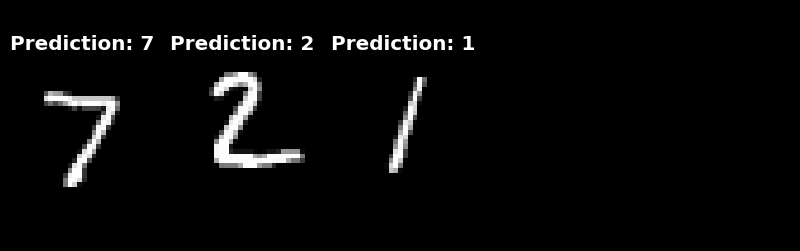

In [9]:
from data_science.util import print_images_in_subfigures

print_images_in_subfigures.print_images_in_subfigures(
    images=x_test, labels=y_pred, subtitle_prefix="Prediction", figsize=(10, 3)
)

##### Querying TF Serving through the gRPC API

In [17]:
# input_name = "flatten_input"
input_name = "conv2d_input"

In [18]:
from tensorflow_serving.apis.predict_pb2 import PredictRequest

request = PredictRequest()
request.model_spec.name = "mnist_model"
request.model_spec.signature_name = "serving_default"
request.inputs[input_name].CopyFrom(tf.make_tensor_proto(x_test))
request

model_spec {
  name: "mnist_model"
  signature_name: "serving_default"
}
inputs {
  key: "conv2d_input"
  value {
    dtype: DT_FLOAT
    tensor_shape {
      dim {
        size: 3
      }
      dim {
        size: 28
      }
      dim {
        size: 28
      }
      dim {
        size: 1
      }
    }
    tensor_content: "\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\000\0

In [19]:
import grpc
from tensorflow_serving.apis import prediction_service_pb2_grpc

channel = grpc.insecure_channel("localhost:8500")
predict_service = prediction_service_pb2_grpc.PredictionServiceStub(channel)
response = predict_service.Predict(request, timeout=10.0)
response

outputs {
  key: "dense_1"
  value {
    dtype: DT_FLOAT
    tensor_shape {
      dim {
        size: 3
      }
      dim {
        size: 10
      }
    }
    float_val: -4.3865924
    float_val: -2.4823349
    float_val: 1.6174709
    float_val: -0.035375632
    float_val: -4.7459693
    float_val: -4.1011753
    float_val: -11.073732
    float_val: 18.240274
    float_val: -4.4090147
    float_val: -0.33438516
    float_val: 1.4806389
    float_val: 2.5001147
    float_val: 16.264423
    float_val: -2.554602
    float_val: -12.395149
    float_val: -9.91908
    float_val: -6.012248
    float_val: -2.4869447
    float_val: 1.6106114
    float_val: -7.087176
    float_val: -2.6199317
    float_val: 10.037762
    float_val: -4.8650856
    float_val: -8.164254
    float_val: -4.2723584
    float_val: -2.8046763
    float_val: -3.956695
    float_val: 1.6430349
    float_val: -0.81482404
    float_val: -6.239356
  }
}
model_spec {
  name: "mnist_model"
  version {
    value: 2
  }
  signa

In [20]:
output_name = "dense_1"
outputs_proto = response.outputs[output_name]
y_prob = tf.make_ndarray(outputs_proto)
y_pred = np.argmax(y_prob, axis=1)
y_pred

array([7, 2, 1])